# In-class Session: Materials Project · Experimental Databases · Phase Diagrams
AI for Materials Science — Hands-on session 1

Today we will search a computational database for materials that meet a set of conditions, pull in
some experimental data, and build a phase diagram from calculated energies.
Sections A to C are worked examples; in section D you build a phase diagram yourself, and that is
what you submit for attendance.

## Today's plan

### 0 · Setup
Install the libraries, download the course data, and paste in your MP API key.
If the key does not work, you paste the path of one Excel file in the same cell instead, and every
query in the notebook reads from that file. Nothing else changes.

### A · Querying the Materials Project
Learn to turn a question into search conditions, and collect the matching materials into a table.

### B · Experimental databases through matminer
Load experimental datasets from different sources through one interface, and check row counts and
missing values.

### C · Phase diagrams (worked example)
Build the Li–Fe–O convex hull from calculated energies, and label every point with the material it
stands for.

### D · Assignment (attendance)
Repeat section C on the Li–Ni–O system, queried from MP yourself. The figure and the table you
produce are what you submit.

---

Run the cells one at a time from the top.
Later cells reuse variables created in earlier ones, so skipping ahead gives you a "name is not
defined" error.
Lines starting with `##` inside the code are comments written for you; Python does not run them.

## 0. Setup

Four things to get in place: the libraries, the course data, an output folder, and your MP API key.

### 0-1. Install the libraries
`pymatgen` handles compositions, structures and phase diagrams, `mp_api` queries the Materials
Project, and `matminer` loads experimental datasets.
NumPy, pandas and matplotlib come along with them.

In [ ]:
## A leading ! runs a terminal command instead of Python.
!pip install -q pymatgen mp_api matminer openpyxl

### 0-2. Download the course material
All of today's data lives in the `Data/` folder of the course repository.
The calculated entries (`Li-Fe-P-O_entries.json`) and the four experimental datasets come down
together, so there are no separate downloads during class.

If you run this a second time you will see a "destination path already exists" message. That is
harmless.

In [ ]:
!git clone https://github.com/kwongibaek/MS49900-AI4M.git

### 0-3. Import the libraries
Installing and importing are two different steps. Installing puts files on the machine; `import`
brings a tool into this notebook.

In [ ]:
## Standard Python tools for paths and for inspecting function signatures.
import inspect
from pathlib import Path

## np for numeric work, pd for tables, plt for figures.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Restoring saved calculation data, and the pymatgen tools for compositions and phase diagrams.
from monty.serialization import loadfn
from pymatgen.core import Composition
from pymatgen.analysis.phase_diagram import PhaseDiagram, PDPlotter

## The MP query client, and the matminer helpers that load experimental datasets.
from mp_api.client import MPRester
from mp_api.client.routes.materials.summary import SummaryRester
from matminer.datasets import load_dataset, get_available_datasets, get_dataset_description

### 0-4. Set the file paths
We decide once which folder to read from and where results go.
Running the cell prints the list of files inside `Data/`.
If you get an error instead of a list, check that you ran the `git clone` cell in 0-2.

In [ ]:
## The Data folder inside the repository downloaded in 0-2.
DATA_DIR = Path("MS49900-AI4M/Data")

## Every table, figure and submission file from today is saved here.
OUTPUT = Path("outputs/02_inclass")
OUTPUT.mkdir(parents=True, exist_ok=True)

sorted(path.name for path in DATA_DIR.iterdir())

### 0-5. Where today's data comes from
Paste your API key between the quotes on the `API_KEY` line and run the cell. You can get a key for
free from the [MP account page](https://next-gen.materialsproject.org/api). Every query in the
notebook then goes to the Materials Project through the `mpr` client this cell builds.

**A key alone is not a guarantee.** When a whole class queries at once the server sometimes refuses
or times out. So the notebook always keeps the saved copies within reach: if a query does not come
back, that cell prints what went wrong and reads the saved result of the same query instead. You do
not have to do anything, and the rest of the notebook carries on unchanged.

**If you have no key**, leave the line as it is. The cell says `saved copies`, and every query reads
from the spreadsheet that came with the course data in 0-2.

`SAVED_XLSX` only matters if your copy of the spreadsheet is somewhere other than the folder cloned
in 0-2 — if you uploaded it by hand, for instance. In the Files pane on the left, right-click the
file, choose **Copy path**, and paste it between the quotes.

The cell prints which of the two you started on. Check that line before moving on.

In [ ]:
## Put your own API key here, between the quotes.
API_KEY = "your_api_key_here"

## Only if your saved copy is somewhere other than the folder cloned in 0-2:
## Files pane -> right-click the file -> Copy path -> paste it between the quotes.
SAVED_XLSX = ""

## ---------------------------------------------------------------------------
## Everything below follows from those two lines. You do not need to edit it.

## The saved copies stay within reach even when the key works, because a query can still fail.
SAVED_XLSX = Path(SAVED_XLSX) if SAVED_XLSX else DATA_DIR / "Hands_on_session1_data.xlsx"
SAVED_ENTRIES = SAVED_XLSX.parent / "Li-Ni-O_entries.json.gz"

## An MP key is 32 characters long. Without one, every query reads the saved copy.
USE_SAVED = len(API_KEY) != 32
mpr = None if USE_SAVED else MPRester(API_KEY)

if USE_SAVED:
    print("Data source: saved copies in", SAVED_XLSX.parent)
else:
    try:
        print("Data source: Materials Project, database version", mpr.db_version)
    except Exception as error:
        print(f"Data source: Materials Project (version unavailable: {type(error).__name__})")
    print("If a query does not come back, that cell reads the saved copy and says so.")

## A. Finding materials that meet your conditions in the Materials Project

Using a materials database really comes down to **turning your question into search conditions**.
Even for something as simple as "show me LiFePO₄", the condition you need differs depending on
whether you want the structures at that composition or every compound containing those elements.

### First, three terms worth separating

- **material** — one representative crystal structure. It carries an ID such as `mp-19017`.
- **task** — one individual DFT calculation. A single material has several tasks behind it.
- **entry** — an object holding a composition together with a calculated energy. This is what phase
  diagrams are built from.

The same composition can correspond to several materials when the atoms are arranged differently.
And you should not assume that the band gap and the energy shown in a summary came from the **same
task**.

### A-1. Conditions change with the question
Work out what each of these five covers. We will use four of them directly in this section.

- `formula="LiFePO4"` — every structure at that composition. Several rows if there are polymorphs.
- `chemsys="Li-Fe-P-O"` — compounds made of exactly these four elements.
- `elements=["Li","Fe","P","O"]` — anything containing these four. Extra elements are allowed.
- `get_entries_in_chemsys([...])` — **all subsystems**, down to elements and binaries. Required for
  phase diagrams.
- `formula="AB"` — a ratio without naming the elements (an anonymous formula). Useful for sweeping
  1:1 compounds.

Full syntax is in
[Querying data](https://docs.materialsproject.org/downloading-data/using-the-api/querying-data) and
[API examples](https://docs.materialsproject.org/downloading-data/using-the-api/examples).

### A-2. Seeing the scope of three conditions
Before asking the server, let us count how many entries each condition selects using the calculation
data we already have.
The file here holds 859 calculated Li–Fe–P–O entries published with pymatgen.

Notice how far apart the numbers are. Pick the wrong condition and you are looking at a completely
different set from the one you meant.

In [ ]:
## loadfn restores a saved JSON file back into the original list of entry objects.
reference_entries = loadfn(DATA_DIR / "Li-Fe-P-O_entries.json")

print("Entries in the calculation data:", len(reference_entries))
print("First entry:", reference_entries[0].entry_id, reference_entries[0].composition.reduced_formula)

In [ ]:
## Collect the element symbols of one entry into a set, with duplicates removed.
def element_set(entry):
    return {element.symbol for element in entry.composition.elements}

lfp_set = {"Li", "Fe", "P", "O"}

## == tests for exactly the same element set; <= tests for a subset.
formula_hits = [e for e in reference_entries if e.composition.reduced_formula == "LiFePO4"]
exact_hits = [e for e in reference_entries if element_set(e) == lfp_set]
subsystem_hits = [e for e in reference_entries if element_set(e) <= lfp_set]

pd.DataFrame([
    {"condition": "formula LiFePO4", "entries selected here": len(formula_hits)},
    {"condition": "exactly Li-Fe-P-O", "entries selected here": len(exact_hits)},
    {"condition": "all subsystems too", "entries selected here": len(subsystem_hits)},
])

### A-3. Checking what you can ask for and what you can get back
Before writing a query, it pays to look at **the conditions it accepts** and **the fields it can
return**.

`inspect.signature` lists the argument names a function takes. No server connection needed.
`available_fields` is the list of fields you can actually retrieve, and only the server knows it, so
on the saved-copies path the second cell has nothing to show and says so. The fields the notebook
actually uses are written out in `SUMMARY_FIELDS` in A-4.

In [ ]:
## List the condition names the query function accepts.
print("Conditions accepted by summary.search:")
print(list(inspect.signature(SummaryRester.search).parameters))

In [ ]:
## available_fields asks the server for the list, so it only runs on the API path.
if USE_SAVED:
    print("You are on the saved copies, so there is nothing to ask the server here.")
    print("The fields the notebook uses are listed in SUMMARY_FIELDS in A-4.")
else:
    try:
        fields = mpr.materials.summary.available_fields
        print("Number of fields available from summary:", len(fields))
        print(fields[:20], "...")
    ## This list lives only on the server, so there is no saved copy to fall back to.
    except Exception as error:
        print(f"The Materials Project did not answer ({type(error).__name__}).")
        print("Skip this one; the fields the notebook uses are in SUMMARY_FIELDS in A-4.")

### A-4. A helper that turns search results into a table
MP returns results as a list of document objects. Unpacking those by hand every time is tedious, so
we write one helper that pulls out the fields we need as a DataFrame and reuse it throughout section
A.

Units are written into the column names: band gap in eV, energies in eV/atom, density in g/cm³.

In [ ]:
## The fields to request. Without this, far more comes back than we need.
SUMMARY_FIELDS = ["material_id", "formula_pretty", "chemsys", "nelements", "nsites",
                  "band_gap", "energy_above_hull", "formation_energy_per_atom",
                  "is_stable", "density", "symmetry"]

## Column names for the table. Putting units in the name saves confusion later.
FRAME_COLUMNS = ["material_id", "formula", "chemsys", "nelements", "nsites", "band_gap_eV",
                 "e_hull_eV_atom", "formation_eV_atom", "is_stable", "density_g_cm3",
                 "spacegroup", "spacegroup_number"]

In [ ]:
## Take a list of documents and return a table with one material per row.
def summary_to_frame(docs):
    rows = []
    for doc in docs:
        ## symmetry is not a single value but an object holding a symbol and a number, so we go one level deeper.
        sym = doc.symmetry
        rows.append(dict(zip(FRAME_COLUMNS, [
            str(doc.material_id), doc.formula_pretty, doc.chemsys, doc.nelements, doc.nsites,
            doc.band_gap, doc.energy_above_hull, doc.formation_energy_per_atom,
            doc.is_stable, doc.density,
            getattr(sym, "symbol", None), getattr(sym, "number", None),
        ])))
    return pd.DataFrame(rows, columns=FRAME_COLUMNS)

One more helper, so the three searches below stay short. It sends the query and hands back the
table; nothing else.

In [ ]:
## One function for both paths. sheet_name says where this query's saved copy lives.
def mp_summary_search(sheet_name, **conditions):
    if not USE_SAVED:
        try:
            docs = mpr.materials.summary.search(
                fields=SUMMARY_FIELDS, all_fields=False,
                num_chunks=1, chunk_size=200, **conditions)
            return summary_to_frame(docs)
        ## A busy server, a rate limit or a dropped connection all land here. Only this one
        ## query failed, so we read the saved result of the same query and carry on.
        except Exception as error:
            print(f"  The Materials Project did not answer ({type(error).__name__}).")
    ## A sheet is one fixed result, so the conditions above are not applied to it. Say so, or a
    ## changed condition looks like it did nothing. The sheet holds exactly the columns
    ## summary_to_frame produces, so nothing downstream can tell the two paths apart.
    print(f"  Saved copy: sheet {sheet_name}. The conditions above are not re-applied to it.")
    return pd.read_excel(SAVED_XLSX, sheet_name=sheet_name)

### A-5. Querying the structures at the LiFePO₄ composition
Our first query. We ask for every structure at this composition with `formula="LiFePO4"` and sort by
distance to the hull.

`num_chunks=1, chunk_size=200` means "return at most 200 records in one go".
So **do not read the row count as the total number of matches in the database**.
If you get exactly 200 rows, suspect there are more.

In [ ]:
lfp_df = mp_summary_search("A5_LiFePO4", formula="LiFePO4")
lfp_df.to_csv(OUTPUT / "mp_lfp_summary.csv", index=False)

print("Rows returned:", len(lfp_df))
lfp_df.sort_values("e_hull_eV_atom").head(10)

### A-6. Stacking conditions to narrow candidates: 1:1 binary oxides
This time we stack several conditions the way a real screening would.
We are after **1:1 binary oxides within 0.05 eV/atom of the hull with a band gap between 1 and 4 eV**.

- `chemsys="*-O"` — binary systems containing oxygen
- `formula="AB"` — the two elements in a 1:1 ratio
- `energy_above_hull=(0, 0.05)` — on or very near the hull
- `band_gap=(1, 4)` — the semiconducting range

A small `energy_above_hull` only means the material is stable against decomposition *within this
calculation model*.
Whether it can actually be synthesised is a separate question.

In [ ]:
ao_df = mp_summary_search(
    "A6_AO_oxides",
    chemsys="*-O", formula="AB", num_elements=2,
    energy_above_hull=(0, 0.05), band_gap=(1, 4))
ao_df.to_csv(OUTPUT / "mp_AO_candidates.csv", index=False)

print("Candidates passing the conditions:", len(ao_df))
ao_df.sort_values(["e_hull_eV_atom", "band_gap_eV"]).head(15)

### A-7. When server-side conditions are not enough: R-3m LiXO₂
`formula="ABC2"` only says "three elements in a 1:1:2 ratio". It **cannot say which element is the 1
and which is the 2.**
A composition with 2 Li and 1 O matches just as well.

So we do it in two stages: cast a wide net on the server, then filter what comes back using pymatgen
`Composition`.
It is a good illustration of where the API stops and your own code takes over.

In [ ]:
## Reduce the formula to its simplest ratio, then check for exactly 1 Li and 2 O.
def is_lixo2(formula):
    comp = Composition(formula).reduced_composition
    ## np.isclose allows for floating-point error when testing "equal".
    return (len(comp.elements) == 3 and np.isclose(comp["Li"], 1)
            and np.isclose(comp["O"], 2) and np.isclose(comp.num_atoms, 4))

## See how the function judges a few examples before using it on real results.
{f: is_lixo2(f) for f in ["LiCoO2", "LiFeO2", "Li2FeO", "LiFePO4"]}

In [ ]:
## Narrow on the server first: stable ternary ABC2 candidates in space group 166 (R-3m).
lxo_df = mp_summary_search(
    "A7_ABC2_R3m",
    elements=["Li", "O"], num_elements=3, formula="ABC2",
    spacegroup_number=166, is_stable=True)

## map applies the test to every value in the formula column; loc keeps the rows where it is True.
lixo2_df = lxo_df.loc[lxo_df["formula"].map(is_lixo2)].copy()
lixo2_df.to_csv(OUTPUT / "mp_stable_R3m_LiXO2.csv", index=False)

print(f"Of the {len(lxo_df)} ABC2 candidates the server returned, {len(lixo2_df)} are really LiXO2.")
lixo2_df

### A-8. Practice 1
Rerun the AO search in A-6 with the lower band gap bound changed from `1.0` to `2.0`.

- How many candidates do you get now?
- What are the top three material IDs?
- What kind of materials dropped out when you tightened the condition?

**On the API path**, edit the `band_gap=(1, 4)` line in the A-6 cell and run that cell again. The
server does the filtering and `ao_df` comes back narrower.

**On the saved copies**, editing that line changes nothing. A sheet is one fixed result, so the
cell returns the same 30 rows whatever conditions you write — which is why it prints a reminder
that the conditions are not re-applied. Narrow the table yourself instead:

```python
ao_df.loc[ao_df["band_gap_eV"] >= 2.0]
```

Both routes give the same answer here. What differs is **where the filtering happened** — on the
server, or on your own machine after everything had already come back.

## B. Loading experimental data with matminer

Everything in section A was **calculated**. Now we turn to **measured** values collected from the
literature.

matminer gives you one way (`load_dataset`) to reach experimental datasets that are scattered across
different sources.
matminer is not itself a measurement database; think of it as a single counter serving data of very
mixed origins.

Four datasets today.

- `steel_strength` — 312 steels. Composition plus yield strength, tensile strength and elongation.
  Strengths in MPa, composition in wt%
- `ucsb_thermoelectrics` — 1,093 thermoelectric records. **The same composition measured at a
  different temperature is a different row**
- `matbench_expt_gap` — 4,604 experimental band gaps. Distributed by MP, but measured, not DFT
- `citrine_thermal_conductivity` — 872 thermal conductivity records. Units and measurement
  conditions are mixed in as free text

The point of this section is less the property values themselves and more the habit of asking
**"can I take this table at face value and start computing?"**

### B-1. Seeing what is available
`get_available_datasets` lists the names and `get_dataset_description` explains one of them.
Checking whether data on your topic already exists is where any project starts.

In [ ]:
available = get_available_datasets(print_format=None)
print("Datasets available through matminer:", len(available))

## any is True if at least one of the three search words appears in the name.
print([name for name in available
       if any(word in name for word in ["expt", "steel", "thermoelectric"])])

In [ ]:
print(get_dataset_description("ucsb_thermoelectrics"))

### B-2. Loading all four at once
Give `load_dataset` a name and you get a table. The source does not change how you call it.

We point `data_home` at the folder downloaded in 0-2 and pass `download_if_missing=False`, meaning
"do not go back to the internet during class".

In [ ]:
DATASET_NAMES = ["steel_strength", "ucsb_thermoelectrics",
                 "matbench_expt_gap", "citrine_thermal_conductivity"]

## Collecting the tables into a dictionary lets us pull each one out by name later.
experimental = {}
for name in DATASET_NAMES:
    experimental[name] = load_dataset(name, data_home=str(DATA_DIR), download_if_missing=False)

## shape is (number of rows, number of columns).
{name: frame.shape for name, frame in experimental.items()}

### B-3. Summarising all four in one table
Before looking at any dataset in detail, let us compare size, number of compositions, missing values
and duplicates side by side.
This is a good first table to build whenever you receive new data.

In [ ]:
inventory = []
for name, frame in experimental.items():
    ## The composition column is named either composition or formula depending on the dataset.
    formula_col = "composition" if "composition" in frame else "formula"
    inventory.append({
        "dataset": name,
        "rows": len(frame),
        "columns": frame.shape[1],
        ## nunique counts distinct values, ignoring repeats.
        "unique_composition_strings": frame[formula_col].nunique(),
        ## Two sums over isna() give the number of blank cells in the whole table.
        "missing_cells": int(frame.isna().sum().sum()),
        ## duplicated() counts rows that are identical across every column.
        "fully_duplicated_rows": int(frame.duplicated().sum()),
    })

inventory_df = pd.DataFrame(inventory)
inventory_df.to_csv(OUTPUT / "experimental_dataset_inventory.csv", index=False)
inventory_df

### B-4. Row count and number of valid measurements are different things
`len(df)` counts all rows. `df.count()`, on the other hand, counts **per column, excluding blanks**.
Seeing where those two diverge is the heart of this section.

Let us open the steel data and look at its columns first.

In [ ]:
steel = experimental["steel_strength"]
steel.head()

In [ ]:
## info shows the dtype of each column together with how many rows hold a value.
steel.info()

In [ ]:
## Put valid and missing counts side by side, column by column.
pd.DataFrame({"valid_measurements": steel.count(), "missing": steel.isna().sum()})

`describe()` gives count, mean, standard deviation and quartiles in one go.
Read the `count` row first here too. A smaller count for elongation means that column has blanks.

In [ ]:
## Double brackets select just the three numeric columns to summarise.
steel[["yield strength", "tensile strength", "elongation"]].describe()

### B-5. Why the same composition appears many times
`te` below is the **UCSB thermoelectrics** table, one of the four datasets loaded in B-2. In it, the
same composition **measured at a different temperature is a separate record**.
So deciding "same composition, must be a duplicate" and dropping rows would corrupt the dataset.

Below, count rows that merely share a composition separately from rows that are identical throughout,
and compare. Practice 2 in B-10 works on this same table.

In [ ]:
## The UCSB thermoelectrics table, pulled out of the dictionary built in B-2.
te = experimental["ucsb_thermoelectrics"]
te.head()

In [ ]:
## With subset, only those columns are compared; without it, every column must match.
print("Rows repeating a composition:", int(te.duplicated(subset=["composition"]).sum()))
print("Rows identical in every column:", int(te.duplicated().sum()))

## dropna removes a row if any of the listed columns is blank.
print("Total rows:", len(te))
print("Rows with both temperature and zT:", len(te.dropna(subset=["T [K]", "zT"])))

### B-6. Stored dtype and statistical meaning are not the same
A pandas dtype tells you **how a value is stored on the machine**. It does not tell you **how the
value should be treated statistically**.

- **Nominal** — a name or code with no order (a synthesis method)
- **Ordinal** — ordered, but with no guarantee of even spacing (Mohs hardness)
- **Discrete** — a countable integer quantity (number of atoms in a structure)
- **Continuous** — any real value within a range (temperature, a measured property)

Run the two cells below, then discuss with a partner where each of `crystallinity`, `synthesis`,
`spacegroup`, `T [K]` and `zT` belongs.

In particular, `spacegroup` is stored as a number. **Would its mean mean anything to a materials
scientist?**

In [ ]:
## dtypes lists the stored type of each column.
te.dtypes.rename("pandas dtype").to_frame()

In [ ]:
## Look at the stored type together with the actual values. T [K] is absolute temperature; zT is dimensionless.
te[["crystallinity", "synthesis", "spacegroup", "T [K]", "zT"]].head()

### B-7. Fix the measurement conditions before comparing
You cannot simply take "the material with the highest zT". If the temperatures differ, it is not a
fair comparison.

So we first **restrict to 300–500 K** and then take the maximum zT per composition within that window.
That value is "the highest observed in this window", not "a comparison of all materials at the same
temperature".

In [ ]:
## Drop rows missing a required column, then use between to select 300-500 K inclusive.
te_valid = te.dropna(subset=["T [K]", "zT"]).copy()
te_window = te_valid.loc[te_valid["T [K]"].between(300, 500)]

## groupby collects rows sharing a composition; agg says what to compute for each group.
top_te = (te_window.groupby("composition", as_index=False)
          .agg(n_measurements=("zT", "size"), max_observed_zT=("zT", "max"),
               lowest_T=("T [K]", "min"), highest_T=("T [K]", "max"))
          .sort_values("max_observed_zT", ascending=False))

print(f"{len(te_window)} measurements between 300-500 K, across {len(top_te)} compositions")
top_te.head(10)

In [ ]:
## fig is the whole figure, ax is the plotting area. We scatter every record, before the temperature cut.
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.scatter(te_valid["T [K]"], te_valid["zT"], s=12, alpha=0.35)
ax.set(xlabel="Measurement temperature (K)", ylabel="Experimental zT",
       title="UCSB thermoelectrics: measured records")

fig.tight_layout()
fig.savefig(OUTPUT / "ucsb_zT_vs_T.png", dpi=160)
plt.show()

### B-8. A look at the experimental band gap distribution
`matbench_expt_gap` holds band gaps obtained by measurement.
MP distributes it, but these are **experimental values, not DFT results**. Do not mix them with the
calculated band gaps from section A.

Look at the minimum in the distribution. A lot of zeros means entries measured as metallic are
included.

In [ ]:
gap = experimental["matbench_expt_gap"]

## rename puts the unit into the name of the summary.
gap["gap expt"].describe().rename("Experimental gap (eV)")

### B-9. Decide what counts as a duplicate first
The thermal conductivity data carries units and measurement conditions **as text**.
Columns like these need checking before any numeric column goes into a calculation.

In [ ]:
thermal = experimental["citrine_thermal_conductivity"]

## value_counts counts rows per value. dropna=False counts blanks too.
thermal["k-units"].value_counts(dropna=False)

In [ ]:
## Select the two condition columns together and keep each combination once, to see what was recorded.
thermal[["k_condition", "k_condition_units"]].drop_duplicates().head(12)

In [ ]:
## Count fully identical rows separately from rows that merely share a formula.
full_duplicate_count = int(thermal.duplicated().sum())
formula_repeat_count = int(thermal.duplicated(subset=["formula"]).sum())

print("Rows identical in every column:", full_duplicate_count)
print("Rows merely sharing a formula:", formula_repeat_count)
print("Matches the reference value of 18 for this release:", full_duplicate_count == 18)

Rows that are identical throughout can be cleaned up once you have checked their provenance.
Rows that only share a `formula`, however, may be separate records taken at different temperatures or
conditions, so they must not be dropped wholesale.

### B-10. Practice 2
Work on **`te`, the UCSB thermoelectrics table from B-5**. Extract the records measured at
**500–700 K with zT ≥ 0.8** and save them as a CSV at `OUTPUT / "task_ucsb_500_700K.csv"`.

Four numbers to report:

1. the total number of rows
2. the number of rows after dropping missing values in the required columns
3. the number of rows passing both conditions
4. the number of distinct composition strings among those rows

Then write one sentence on **why you kept multiple rows for the same composition**.

Write it yourself in the empty cell below; this is not a fill-in-the-blank exercise. Work on a copy
(`te.copy()`) so the original table is left intact. The three columns you need are `composition`,
`T [K]` and `zT`.
If you get stuck, look back at the `dropna(subset=...)` and boolean masks used in B-5 and B-7.

In [ ]:
## Write your code here.
## Order: len() -> dropna(subset=...) -> two condition masks -> nunique() -> to_csv()

1. total rows              : 1093
2. after dropna            : 703
3. passing both conditions : 31
4. distinct compositions   : 27
saved: outputs/02_inclass/task_ucsb_500_700K.csv


## C. Building a phase diagram from calculated energies

This is the core of the session. We work through how calculated energies per composition tell you
**which phases are stable**.

We are building the Li–Fe–O ternary phase diagram as a worked example.
Change the elements and the same code gives you any other ternary system, which is exactly what you
will do in section D.

### Why querying `chemsys= "Li-Fe-O"` is not enough
Fetching only the strictly ternary compounds leaves out the **elemental references** such as Li, Fe
and O₂, and the **competing binaries** such as Li₂O and Fe₂O₃.
Without anything to compare against you cannot build a convex hull. Restricting to `is_stable=True`
has the same problem: with no unstable phases, you cannot measure *how* unstable something is.

So a phase diagram needs **every subsystem — elements, binaries and ternaries alike**.
That is the job of `get_entries_in_chemsys`, which we met in A-1.

### C-1. Selecting the entries for the phase diagram
Today we take the Li·Fe·O subsystem out of the calculation data we already read in A-2.
Because the dataset is version-pinned, everyone in the room sees the same figure.

Check that **all three elemental references are present** in the output. If even one is missing, the
hull cannot be built.

In [ ]:
PD_ELEMENTS = ["Li", "Fe", "O"]

## Reuse the element_set helper from A-2. Keep entries whose elements fall inside Li-Fe-O.
pd_entries = [e for e in reference_entries if element_set(e) <= set(PD_ELEMENTS)]
phase_source = "pymatgen historical fixture 0428f232a569 | stored GGA/GGA+U corrections"

print("Entries in this system:", len(pd_entries))
print("Elemental references:", sorted({e.composition.reduced_formula
                                       for e in pd_entries if e.composition.is_element}))

### C-2. Computing the hull and telling three energies apart
Hand `PhaseDiagram` a list of entries and it computes the convex hull and the set of stable phases.

The table has three energy columns. **Make sure you can tell them apart.**

- `corrected_energy_eV_atom` — the per-atom energy of that calculation. Not comparable across
  materials
- `formation_energy_eV_atom` — formation energy relative to the elemental references. More negative
  means more stable than the elements
- `energy_above_hull_eV_atom` — distance to the hull. **Zero means stable in this system**; larger
  means easier to decompose

The formation energy here comes from a 0 K electronic structure calculation.
Treating the solid `pV` term as small, it works as an approximation to the 0 K formation enthalpy,
but it is not the finite-temperature Gibbs free energy.

In [ ]:
## The convex hull is computed from the compositions and corrected energies of the input entries.
phase_diagram = PhaseDiagram(pd_entries)

phase_rows = []
for entry in pd_entries:
    phase_rows.append({
        "entry_id": str(entry.entry_id),
        "formula": entry.composition.reduced_formula,
        "n_atoms_in_entry": entry.composition.num_atoms,
        "corrected_energy_eV_atom": entry.energy_per_atom,
        "formation_energy_eV_atom": phase_diagram.get_form_energy_per_atom(entry),
        "energy_above_hull_eV_atom": phase_diagram.get_e_above_hull(entry),
        ## in tests whether this entry belongs to the set of stable phases.
        "stable_in_this_PD": entry in phase_diagram.stable_entries,
        "run_type": entry.parameters.get("run_type"),
    })

phase_df = pd.DataFrame(phase_rows).sort_values(["energy_above_hull_eV_atom", "formula"])

print("Stable entries:", int(phase_df["stable_in_this_PD"].sum()), "/", len(phase_df))
phase_df.head(20)

### C-3. Drawing the phase diagram
`PDPlotter` draws the hull on a triangle. `show_unstable=False` keeps only the stable phases.

How to read it:

- **Vertices** — pure elements
- **Edges** — binary compounds
- **Interior** — ternary compounds
- **Phases joined by a line** — combinations that can coexist at compositions in between

Every point on the hull is one material, so we need to know which is which.
Writing the formula next to each point works until the points crowd together, which they do in most
systems.
Instead we number the points and print an index pairing each number with its formula and material ID.
The index is printed **just above the figure**, so you can read the two together.

The helper below works for any ternary system, so you will reuse it for your own system in section D.

The figure is based on 0 K energies from a fixed calculation model. Temperature, pressure and
reaction kinetics are not in it.

In [ ]:
## Number every stable point and return a table pairing the numbers with the materials.
def label_stable_points(plotter, phase_diagram, ax):
    points = plotter.pd_plot_data[1]
    ## The centre of all the points. Labels are pushed outward from here so they do not sit on the lines.
    xs = [x for x, _ in points]
    ys = [y for _, y in points]
    cx, cy = sum(xs) / len(xs), sum(ys) / len(ys)

    ## Sort by position so the numbering runs bottom-left to top in a predictable order.
    ordered = sorted(points.items(), key=lambda kv: (round(kv[0][1], 6), kv[0][0]))

    rows = []
    for n, ((x, y), entry) in enumerate(ordered, start=1):
        dx, dy = x - cx, y - cy
        norm = (dx * dx + dy * dy) ** 0.5 or 1.0
        ## Alternating the distance keeps the numbers apart where points are crowded.
        radius = 20 if n % 2 else 32
        ax.annotate(str(n), xy=(x, y),
                    xytext=(radius * dx / norm, radius * dy / norm),
                    textcoords="offset points", ha="center", va="center",
                    fontsize=9, fontweight="bold", color="#b3261e",
                    bbox=dict(boxstyle="circle,pad=0.18", facecolor="white",
                              edgecolor="#b3261e", linewidth=0.7, alpha=0.95),
                    arrowprops=dict(arrowstyle="-", color="#b3261e", lw=0.6),
                    annotation_clip=False)
        rows.append({"point": n,
                     "formula": entry.composition.reduced_formula,
                     "material_id": str(entry.entry_id),
                     "e_hull_eV_atom": round(phase_diagram.get_e_above_hull(entry), 6)})
    return pd.DataFrame(rows)

In [ ]:
plotter = PDPlotter(phase_diagram, backend="matplotlib", show_unstable=False,
                    linewidth=1.5, markersize=7)
## Turn off the built-in labels; the helper places numbered ones instead.
ax = plotter.get_plot(label_stable=False, label_unstable=False)
ax.set_aspect("equal", adjustable="box")

phase_fig = ax.figure
phase_fig.set_size_inches(8, 7)

phase_legend = label_stable_points(plotter, phase_diagram, ax)
ax.set_title("Li-Fe-O | corrected GGA/GGA+U | historical reference")
phase_legend.to_csv(OUTPUT / "phase_diagram_points.csv", index=False)
phase_fig.savefig(OUTPUT / "phase_diagram.png", dpi=180, bbox_inches="tight")

## Print the index first so it sits directly above the figure.
print(f"Li-Fe-O: {len(phase_legend)} stable phases")
print(phase_legend.to_string(index=False))
print()

## plt.show() draws the figure underneath the index.
plt.show()

Every numbered point on the diagram appears in the index above, with its formula and MP material ID.
All of them have `e_hull_eV_atom` equal to 0, because only stable phases were drawn.

The index is also saved as `phase_diagram_points.csv`, so you can open it next to the figure later.

### C-4. Same formula, different structures: LiFeO₂ polymorphs
The figure shows only stable phases, but the dataset actually contains several structures at the
LiFeO₂ composition.

Comparing their distances to the hull reveals **which structure is the stable one**.
It also shows what the unstable ones decompose into.

In [ ]:
same_formula = [e for e in pd_entries if e.composition.reduced_formula == "LiFeO2"]

lifeo2_rows, lifeo2_product_ids = [], set()
for entry in same_formula:
    ## This function returns the decomposition products and the hull distance together.
    decomposition, e_hull = phase_diagram.get_decomp_and_e_above_hull(entry)
    products = [f"{e.entry_id}:{e.composition.reduced_formula}" for e in decomposition]
    lifeo2_product_ids.update(str(e.entry_id) for e in decomposition)
    lifeo2_rows.append({"entry_id": str(entry.entry_id),
                        "energy_above_convex_hull_eV_atom": float(e_hull),
                        "decomposition_products": " + ".join(products)})

lifeo2_polymorphs = (pd.DataFrame(lifeo2_rows)
                     .sort_values("energy_above_convex_hull_eV_atom")
                     .reset_index(drop=True))

print("LiFeO2 polymorphs:", len(lifeo2_polymorphs))
print("Decomposition product IDs:", lifeo2_product_ids)
lifeo2_polymorphs

Two things to take from that table.

First, the hull distance in the top row is 0. That is the stable phase, the LiFeO₂ whose label appears
in the figure.
The bottom row sits about 0.34 eV/atom away. Same chemical formula, that much difference.

Second, every unstable polymorph decomposes into **the same single phase (`mp-851027`)**.
Since the composition is identical, so is what it decomposes into. The next cell shows what happens
when the composition differs.

### C-5. A different composition gives several products: LiFe₂O₄
`mp-25516` (LiFe₂O₄) lies a little above the hull and **decomposes into three phases**.

The weights returned by `get_decomp_and_e_above_hull` are **atomic fractions**, which are not the
same as reaction coefficients.
Below we convert them into coefficients per formula unit.

In [ ]:
## Take the first entry in the list matching this condition.
target = next(e for e in pd_entries if str(e.entry_id) == "mp-25516")
decomposition, target_e_hull = phase_diagram.get_decomp_and_e_above_hull(target)

## Atom count of the reduced formula. LiFe2O4 has 7.
target_atoms = Composition(target.composition.reduced_formula).num_atoms

decomposition_rows = []
for product, weight in decomposition.items():
    product_atoms = Composition(product.composition.reduced_formula).num_atoms
    decomposition_rows.append({
        "phase_entry_id": str(product.entry_id),
        "phase_formula": product.composition.reduced_formula,
        "atomic_fraction_weight": float(weight),
        ## atomic fraction x target atom count / product atom count = coefficient per formula unit
        "coefficient_per_target_formula": float(weight) * target_atoms / product_atoms,
    })

print(f"{target.entry_id} ({target.composition.reduced_formula}) "
      f"| {float(target_e_hull):.6f} eV/atom above the hull | {target_atoms:.0f} atoms")
pd.DataFrame(decomposition_rows).sort_values("phase_entry_id")

Reading off the coefficient column gives a balanced decomposition reaction.

$$\mathrm{LiFe_2O_4 \rightarrow LiFeO_2 + \tfrac{1}{2}\,Fe_2O_3 + \tfrac{1}{4}\,O_2}$$

Multiplying the atomic fractions `4/7`, `5/14` and `1/14` by `7 / product atom count` (4, 5 and 2)
gives 1, 1/2 and 1/4.

## D. Assignment: build a phase diagram yourself

Section C was the worked example, and you watched it being built. Li–Fe–O came out of a bundled file,
so everyone saw the same figure and could check against the same numbers.

Now you build one yourself, on **Li–Ni–O**, queried from the Materials Project. This is what counts
for attendance.

Li–Ni–O is the system behind LiNiO₂ and the Ni-rich layered cathodes, so it is a hull worth having
looked at. Everyone in the room builds the same one, which means you can compare your figure with
your neighbour's and any difference is something to explain, not something to shrug at.

### What changes compared with section C
- The entries come from `mpr.get_entries_in_chemsys(...)` instead of a file, so you are reading the
  current database rather than a fixed snapshot.
- The system is different, so the shape of the hull and the phases sitting on it are different.
- Everything else — `PhaseDiagram`, `PDPlotter`, `label_stable_points` — is reused unchanged.

### D-1. Set your student ID
Your ID is only used to name the files you submit.

In [ ]:
## Replace this with your own student ID. It only goes into the names of your submission files.
STUDENT_ID = "demo"

if STUDENT_ID == "demo":
    raise ValueError("Set STUDENT_ID to your own student ID before running this cell.")

## Everyone builds the same system today.
MY_ELEMENTS = ["Li", "Ni", "O"]
MY_SYSTEM = "-".join(MY_ELEMENTS)

print("Student ID:", STUDENT_ID)
print("System:", MY_SYSTEM)

### D-2. Fetch the entries for Li–Ni–O
Section C read its entries from a file. Here they come from `get_entries_in_chemsys`, which returns
**every subsystem** — Li, Ni and O₂ themselves, and the binaries such as Li₂O and NiO, as well as the
ternary compounds. That is the part you must not skip. Without the elemental references there is
nothing for the hull to be built against, and `PhaseDiagram` refuses to build at all rather than
quietly giving you a wrong answer.

Two arguments are worth understanding.

- `compatible_only=True` applies the energy corrections MP fits for oxides and for GGA+U transition
  metals. The hull assumes corrected energies, so leaving this off changes the answer.
- `additional_criteria={"thermo_types": ["GGA_GGA+U"]}` pins the calculation family. Left out, the
  query returns MP's **mixed** set, where r2SCAN energies replace the GGA+U ones for materials that
  have them. Both are legitimate hulls, but they are different hulls, and pinning it is what makes
  your numbers comparable with everyone else's.

The query takes a few seconds. The last line checks the three elemental references actually
arrived.

Entries are objects, not rows, so the saved copy of this one is a `.json.gz` file rather than a
sheet in the spreadsheet, and it sits in the same folder. As in section A, the cell falls back to
it only if the query does not come back. `loadfn` reads it with the same compositions, the same
corrected energies and the same material IDs, so `PhaseDiagram` in D-3 gives the same hull either
way.

In [ ]:
my_entries, my_source = None, None

if not USE_SAVED:
    try:
        my_entries = mpr.get_entries_in_chemsys(
            MY_ELEMENTS, compatible_only=True,
            additional_criteria={"thermo_types": ["GGA_GGA+U"]})
        my_source = "live query"
    ## Same as in section A: if the server is busy, fall back for this one query.
    except Exception as error:
        print(f"The Materials Project did not answer ({type(error).__name__}).")
        print("Reading the saved entries instead.")

if my_entries is None:
    ## Entries are objects, not rows, so their saved copy is a .json.gz beside the spreadsheet.
    ## loadfn is to .json.gz what read_excel is to .xlsx.
    my_entries = loadfn(SAVED_ENTRIES)
    my_source = "saved copy"

print("System:", MY_SYSTEM)
print("Source:", my_source)
print("Entries:", len(my_entries))

## All three must appear here, or the hull cannot be built.
print("Elemental references:",
      sorted({e.composition.reduced_formula for e in my_entries if e.composition.is_element}))

### D-3. Build and draw the phase diagram
Now the part you write yourself. Four steps, all of them shown in section C.

1. Build the hull with `PhaseDiagram(...)`.
2. Draw it with `PDPlotter(..., backend="matplotlib", show_unstable=False)` and
   `get_plot(label_stable=False, label_unstable=False)`.
3. Number the points with `label_stable_points(plotter, my_phase_diagram, ax)`.
4. Print the index with `print(my_legend.to_string(index=False))` **before** `plt.show()`, so it
   lands directly above your figure the way section C did.

Store your results under these names, because the submission cell looks for them:

- `my_phase_diagram` — the `PhaseDiagram` object
- `my_fig` — the matplotlib figure
- `my_legend` — the table returned by `label_stable_points`

Before you move on, check that all three elemental references appear in your table. If one is
missing, the hull is not complete.

Li-Ni-O: 11 stable phases
 point   formula      material_id  e_hull_eV_atom
     1        Li   mp-1018134-GGA             0.0
     2        Ni        mp-23-GGA             0.0
     3      Li2O      mp-1960-GGA             0.0
     4     Li2O2       mp-841-GGA             0.0
     5   Li2NiO3  mp-556550-GGA+U             0.0
     6    LiNiO2 mp-2348641-GGA+U             0.0
     7       NiO   mp-19009-GGA+U             0.0
     8 Li(NiO2)2  mp-774941-GGA+U             0.0
     9     Ni3O4  mp-656887-GGA+U             0.0
    10      LiO8   mp-1235059-GGA             0.0
    11        O2     mp-12957-GGA             0.0



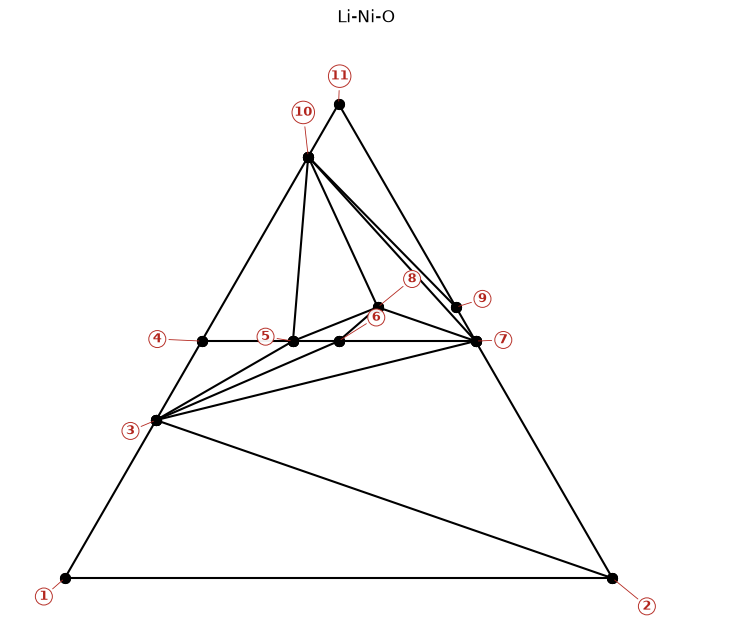

In [ ]:
## Write your code here.
## Order: PhaseDiagram -> PDPlotter -> label_stable_points -> print the index -> plt.show()

### D-4. Save your submission
Running this cell writes two files. Submit both. There is nothing to fill in by hand.

1. `attendance_<id>_Li-Ni-O_phase_diagram.png` — your figure
2. `attendance_<id>_Li-Ni-O_stable_phases.csv` — the numbered index behind it

The cell then restates how many entries you queried, how many phases came out on the hull, and
whether those entries came from a live query or from the saved copy. Read those three numbers before
you submit; they are the check that your run went through properly. If it warns that the hull was
built on something other than Li–Ni–O, go back to D-2 and check what you passed to the query.

In [ ]:
## Stop with a clear message if D-3 has not been completed.
required = ["my_entries", "my_phase_diagram", "my_fig", "my_legend"]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(f"Complete D-3 first. These names are not defined yet: {missing}")

safe_student_id = "".join(c for c in STUDENT_ID if c.isalnum() or c in "_-")
stem = f"attendance_{safe_student_id}_{MY_SYSTEM}"

my_legend.to_csv(OUTPUT / f"{stem}_stable_phases.csv", index=False)
my_fig.savefig(OUTPUT / f"{stem}_phase_diagram.png", dpi=180, bbox_inches="tight")

for suffix in ["phase_diagram.png", "stable_phases.csv"]:
    path = OUTPUT / f"{stem}_{suffix}"
    print(f"{'created' if path.exists() and path.stat().st_size > 0 else 'MISSING'}  {path}")

## The one thing worth checking by eye: the hull was built on the system you were asked for.
## el_refs is keyed by element, so this compares what you actually queried against Li-Ni-O.
queried = sorted(element.symbol for element in my_phase_diagram.el_refs)
print()
print(f"{MY_SYSTEM}: {len(my_entries)} entries, "
      f"{len(my_phase_diagram.stable_entries)} stable phases, from {my_source}")
if queried != sorted(MY_ELEMENTS):
    print(f"WARNING: the hull was built on {'-'.join(queried)}, not on {MY_SYSTEM}.")